# Notebook 01: Synthetic Healthcare Data Generation (ABDM FHIR standard)

## Objective
This notebook generates realistic synthetic clinical EHR (Electronic Health Record) data for multi-disease risk modeling (**Diabetes, Heart Disease, Hypertension, Kidney Disease**) integrated with **ABHA (Ayushman Bharat Health Account) Identifiers** and exports them as tabular CSV and standard **FHIR R4 Bundles**.

### Privacy & Compliance
- **No real patient data** or PII is used.
- All IDs follow the ABDM ABHA specification (`91-XXXX-XXXX-XXXX`).



In [1]:
import os
import sys
# Ensure project root is in sys.path for backend and scripts imports
root_path = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if root_path not in sys.path:
    sys.path.insert(0, root_path)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.synthetic_data_generator import SyntheticHealthcareDataGenerator

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('muted')
print("Environment and dependencies initialized successfully.")


Environment and dependencies initialized successfully.


## 1. Generate Synthetic Patient Dataset
We generate $N = 1,500$ synthetic patient records with non-linear correlations representing realistic risk profiles.


In [2]:
generator = SyntheticHealthcareDataGenerator(seed=42)
df_patients = generator.generate_patients(n_patients=1500)

print(f"Generated {len(df_patients)} synthetic patient records.")
print("\nSample Data (First 5 records):")
df_patients.head()


Generated 1500 synthetic patient records.

Sample Data (First 5 records):


,patient_id,abha_id,age,gender,systolic_bp,diastolic_bp,heart_rate,bmi,glucose,hba1c,cholesterol,creatinine,diabetes,heart_disease,hypertension,kidney_disease
0,SYN-PAT-ae5feb20,91-4481-6772-6336,62,male,147.76,94.10,62,24.86,114.47,5.54,219.64,1.64,1,0,1,0
1,SYN-PAT-abeff718,91-5122-3960-8897,52,female,120.22,83.96,69,21.03,127.03,4.82,199.73,1.21,1,0,0,1
2,SYN-PAT-e1ced68d,91-3469-8051-5068,64,female,110.88,59.33,83,15.00,111.82,5.47,221.86,1.26,0,0,0,0
3,SYN-PAT-5a8a04bb,91-6443-5380-3545,77,male,143.79,85.15,80,25.04,133.13,5.27,237.96,1.54,1,0,1,1
4,SYN-PAT-c893b63c,91-8665-4649-2814,51,male,120.53,60.42,58,38.06,164.40,6.71,229.44,1.11,1,0,1,0


## 2. Statistical Summary of Data Features


In [3]:
print("Summary Statistics of Clinical Vitals & Lab Measurements:")
df_patients[['age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'bmi', 'glucose', 'hba1c', 'cholesterol', 'creatinine']].describe().T


Summary Statistics of Clinical Vitals & Lab Measurements:


,count,mean,std,min,25%,50%,75%,max
age,1500.0,55.216000,14.657623,18.00,45.0000,55.000,65.0000,90.00
systolic_bp,1500.0,129.210287,11.328515,91.10,121.5275,129.370,136.8850,164.92
diastolic_bp,1500.0,77.469893,8.500131,45.02,71.6875,77.730,83.1300,105.42
heart_rate,1500.0,71.079333,9.893953,40.00,64.7500,71.000,78.0000,104.00
bmi,1500.0,26.084927,5.011225,15.00,22.5450,26.075,29.4225,45.63
glucose,1500.0,130.462373,16.923636,80.32,119.1050,130.605,141.8875,191.93
hba1c,1500.0,5.496520,0.700404,2.98,5.0200,5.490,5.9800,7.78
cholesterol,1500.0,208.975060,21.892582,143.71,194.2350,208.415,223.9200,281.30
creatinine,1500.0,1.204547,0.282198,0.40,1.0100,1.200,1.3900,2.06


## 3. Disease Class Distributions


Disease Case Totals:
diabetes          892
heart_disease     129
hypertension      322
kidney_disease    519
dtype: int64


C:\Users\bahad\AppData\Local\Temp\ipykernel_23968\4273060071.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='viridis')


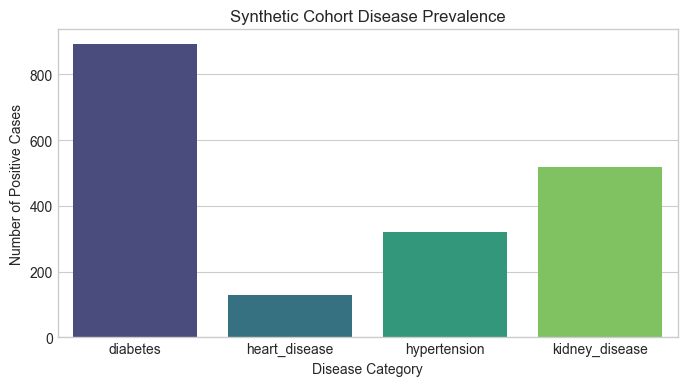

In [4]:
disease_cols = ['diabetes', 'heart_disease', 'hypertension', 'kidney_disease']
disease_counts = df_patients[disease_cols].sum()

print("Disease Case Totals:")
print(disease_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='viridis')
plt.title("Synthetic Cohort Disease Prevalence")
plt.ylabel("Number of Positive Cases")
plt.xlabel("Disease Category")
plt.show()


## 4. Correlation Analysis of Clinical Vitals & Targets


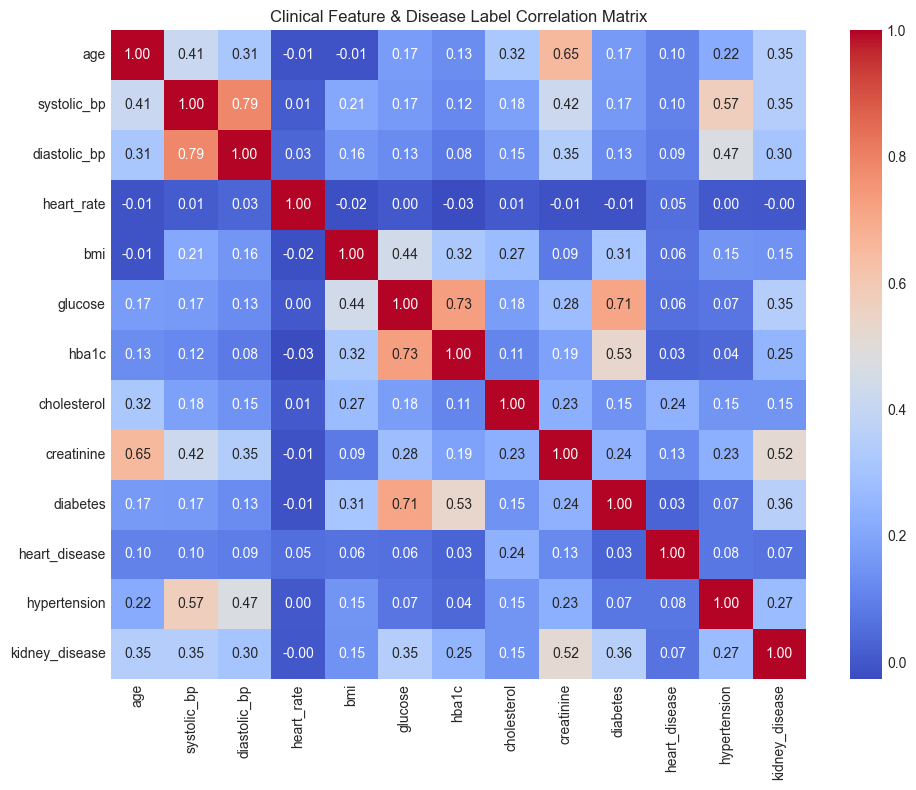

In [5]:
plt.figure(figsize=(10, 8))
numeric_df = df_patients.drop(columns=['patient_id', 'abha_id', 'gender'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Clinical Feature & Disease Label Correlation Matrix")
plt.tight_layout()
plt.show()


## 5. Export Datasets (CSV & ABDM FHIR R4 Bundle JSON)


In [6]:
csv_path = os.path.join(root_path, "data", "generated", "synthetic_patients.csv")
json_path = os.path.join(root_path, "data", "generated", "synthetic_bundle.json")

generator.export(df_patients, csv_path, json_path)

print(f"Successfully saved CSV dataset to: {os.path.abspath(csv_path)}")
print(f"Successfully saved FHIR JSON Bundle to: {os.path.abspath(json_path)}")


Successfully saved CSV dataset to: D:\users\Group Project\FedABHA\data\generated\synthetic_patients.csv
Successfully saved FHIR JSON Bundle to: D:\users\Group Project\FedABHA\data\generated\synthetic_bundle.json
